In [10]:
import pandas as pd

files = [
    "../csvs/chill_indie.csv",
    "../csvs/danceable_pop_vibes.csv",
    "../csvs/high-energy_electronic.csv",
    "../csvs/slow_sad_acoustic.csv"
]

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print("Raw combined shape:", df.shape)

Raw combined shape: (6468, 23)


In [11]:
# Drop tracks that appear under more than one conflicting genre label 

genre_counts = df.groupby('track_id')['track_genre'].nunique()
conflicting_ids = genre_counts[genre_counts > 1].index

print("Tracks with conflicting genre labels across files:", len(conflicting_ids))
df = df[~df['track_id'].isin(conflicting_ids)]

Tracks with conflicting genre labels across files: 702


In [12]:
df = df.drop_duplicates(subset=['track_id']).reset_index(drop=True)   # Drop duplicates based on track_id

print("Final clean shape:", df.shape)
df['track_genre'].value_counts()

Final clean shape: (5042, 23)


track_genre
dubstep        924
ambient        860
sad            710
chill          658
pop            624
indie          541
alternative    342
house          211
edm            172
Name: count, dtype: int64

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

le_genre = LabelEncoder()
y_genre = le_genre.fit_transform(df['track_genre'])

drop_cols = ['track_id', 'artists', 'album_name', 'track_name', 'track_genre']
extra_cols = [c for c in ['Unnamed: 0', 'mood_cluster', 'playlist_name'] if c in df.columns]
X = df.drop(columns=drop_cols + extra_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_genre, test_size=0.2, stratify=y_genre, random_state=42
)

xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le_genre.classes_),
    eval_metric='mlogloss',
    random_state=42
)

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [100, 200],   # Number of trees in the forest   (2 choices)
    'max_depth': [3, 5, 7],     # Maximum depth of the tree (3 choices)
    'learning_rate': [0.01, 0.1, 0.2],    # Controls how aggressively trees learn (3 choices)
    'subsample': [0.7, 1.0],    # Fraction of rows used by each tree (2 choices)
    'colsample_bytree': [0.7, 1.0],     # Fraction of features used by each tree (2 choices)
}

# Total combinations: 2 × 3 × 3 × 2 × 2 = 72 models
# GridSearch trains all 72. Then picks the best.

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid,
                           scoring='f1_weighted',
                           cv=3,
                           verbose=0,
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)  # print the best parameters found by GridSearchCV

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n Classification Report (Tuned XGBoost):")
print(classification_report(y_test, y_pred, target_names=le_genre.classes_))


Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.7}

 Classification Report (Tuned XGBoost):
              precision    recall  f1-score   support

 alternative       0.51      0.48      0.49        69
     ambient       0.93      0.86      0.89       172
       chill       0.51      0.55      0.53       132
     dubstep       0.78      0.88      0.82       185
         edm       0.40      0.18      0.24        34
       house       0.56      0.43      0.49        42
       indie       0.53      0.51      0.52       108
         pop       0.78      0.81      0.79       125
         sad       0.68      0.73      0.70       142

    accuracy                           0.69      1009
   macro avg       0.63      0.60      0.61      1009
weighted avg       0.69      0.69      0.69      1009



In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_model, X, y_genre, cv=5, scoring='f1_weighted')
print(scores, scores.mean())
# this cell basically does the same as the previous block, but it uses cross-validation to evaluate the model's performance on the entire dataset rather than just a single train-test split. It provides a more robust estimate of the model's performance by averaging the scores across multiple folds.

[0.5128802  0.66291365 0.65777956 0.61676134 0.53964512] 0.5979959761120631


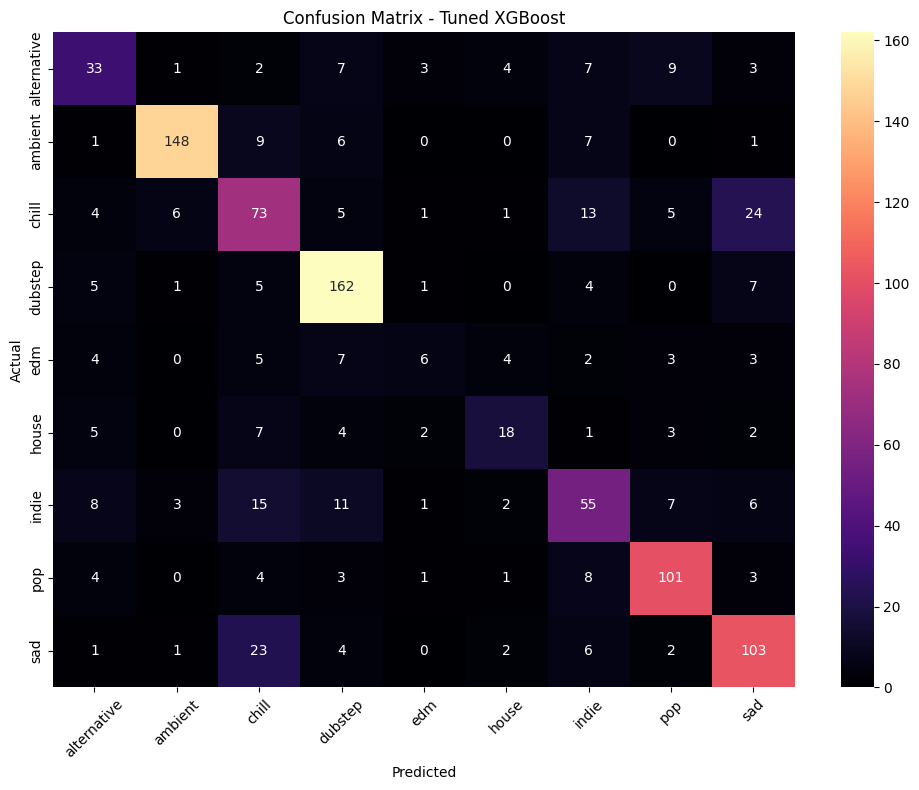

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma',
            xticklabels=le_genre.classes_,
            yticklabels=le_genre.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned XGBoost')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

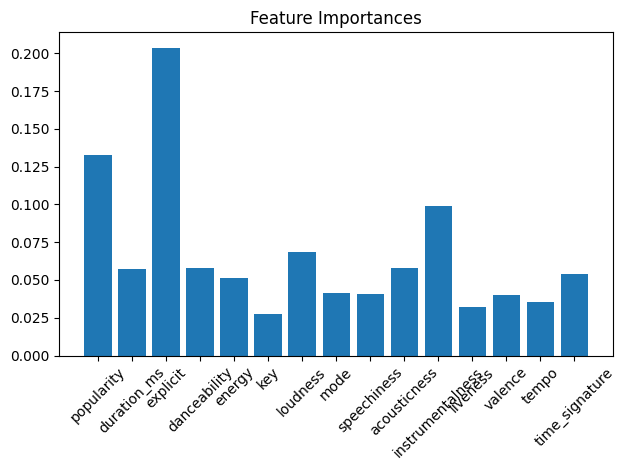

In [16]:
import matplotlib.pyplot as plt
importances = best_model.feature_importances_
plt.bar(range(len(importances)), importances)
plt.xticks(range(len(importances)), X.columns, rotation=45)
plt.title("Feature Importances")
plt.tight_layout()
plt.show()